### baseline_03
- Basic sanity/signal checks have been validated against a meaningful amount of data
- Now moving onto expanding number of core features
- This baseline model will now introduce propellant context to the predictions. Different propellants have their own burn rates and have been ranked in the burn_rate_index feature.
- Burn rate index is a *ranking* system so the values will be an ordinal feature. It will be interesting to see what the model does with this new information

In [1]:
import pandas as pd
import numpy as np

In [7]:
df = pd.read_csv("data/baseline_data_updated.csv")
df.head(5)

,cartridge,bullet_diameter,bullet_brand,bullet_type,bullet_weight,powder_type,burn_rate_index,charge_weight,velocity_fps,barrel_length,data_source,primer,twist_rate,coal,compressed_load,jump_to_lands,amb_temp,pressure,case_capacity,suppressed
0,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n130,84,21.1,3402,25.0,vihtavuori,small_rifle_generic,12.0,2.181,NaN,NaN,NaN,NaN,NaN,NaN
1,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n133,89,22.8,3481,25.0,vihtavuori,small_rifle_generic,12.0,2.181,NaN,NaN,NaN,NaN,NaN,NaN
2,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n135,102,24.7,3514,25.0,vihtavuori,small_rifle_generic,12.0,2.181,NaN,NaN,NaN,NaN,NaN,NaN
3,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n140,112,26.2,3425,25.0,vihtavuori,small_rifle_generic,12.0,2.181,NaN,NaN,NaN,NaN,NaN,NaN
4,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n540,117,25.8,3301,25.0,vihtavuori,small_rifle_generic,12.0,2.181,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
three_oh_eight = df[df["cartridge"].isin(["308_win"])].copy()

features = ["charge_weight", "bullet_weight", "burn_rate_index"]
target = ["velocity_fps"]
X = three_oh_eight[features].astype(float)
y = three_oh_eight[target].astype(float)

In [9]:
from sklearn.linear_model import LinearRegression

model= LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
coeffs = pd.Series(model.coef_.ravel(), index=features)
intercept = model.intercept_
coeffs, intercept

(charge_weight      45.737848
 bullet_weight      -5.205339
 burn_rate_index    -6.670199
 dtype: float64,
 array([2260.62662114]))

### model is appearing to correctly interpret burn rates
- The burn rate index has the fastest powders ranked first, slower powder ranked last
- Should expect to see velocity be driven down by the higher ranks

In [14]:
from sklearn.metrics import mean_absolute_error

mean_pred = np.full_like(y, y.mean())
floor = mean_absolute_error(y, mean_pred)  # floor mae

preds = model.predict(X)
mae_one = mean_absolute_error(y, preds)  # mae based on model learning from our three features

floor, mae_one

(191.9525982565519, 51.50734698041777)

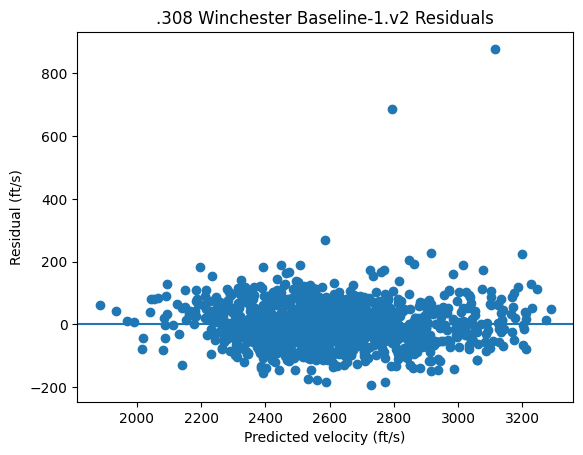

In [13]:
import matplotlib.pyplot as plt

residuals = y - preds

plt.scatter(preds, residuals)
plt.axhline(0)
plt.xlabel("Predicted velocity (ft/s)")
plt.ylabel("Residual (ft/s)")
plt.title(".308 Winchester Baseline-1.v2 Residuals")
plt.show()

### Excellent results from this baseline.
- Floor remains unchanged, confirming that dataset has not shifted and no apparent leakage
- mae drop is significant
  - 72.89 ft/s down to 51.51 ft/s is a 29% reduction in average absolute error from just one additional feature.
  - Not marginal
  - Not noise
  - Not overfitting
  - *Strong, clean signal*
- Residuals are behaving beautifully. The structure of the error did not change but the magnitude of the error shrank.